In [1]:
!apt-get update
!apt-get install libsdl2-gfx-dev libsdl2-ttf-dev libsdl2-image-dev libboost-python-dev libsdl2-dev libboost-filesystem-dev libboost-system-dev libboost-thread-dev

# 2.8 and 2.9 binary is the same, so we use 2.8 .so file
!git clone -b v2.9 https://github.com/google-research/football.git
!mkdir -p football/third_party/gfootball_engine/lib

!wget https://storage.googleapis.com/gfootball/prebuilt_gameplayfootball_v2.8.so -O football/third_party/gfootball_engine/lib/prebuilt_gameplayfootball.so
!cd football && GFOOTBALL_USE_PREBUILT_SO=1 python3 -m pip install .

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,849 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,623 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,537 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,410 kB]
Get:14 http://archive.ubu

In [2]:
import os

engine_path = '/usr/local/lib/python3.12/dist-packages/gfootball_engine'
cmake_list_path = os.path.join(engine_path, 'CMakeLists.txt')

corrected_cmake_content = [
    "cmake_minimum_required(VERSION 3.1)\n",
    "cmake_policy(SET CMP0057 NEW) # Set policy for modern Boost find_package usage\n",
    "\n",
    "set(PACKAGE gameplayfootball)\n",
    "\n",
    "set(VERSION_MAJOR 0)\n",
    "set(VERSION_MINOR 2)\n",
    "set(VERSION_PATCH 0)\n",
    "if(${VERSION_PATCH})\n",
    "   set(VERSION ${VERSION_MAJOR}.${VERSION_MINOR}.${VERSION_PATCH})\n",
    "else(${VERSION_PATCH})\n",
    "   set(VERSION ${VERSION_MAJOR}.${VERSION_MINOR})\n",
    "endif(${VERSION_PATCH})\n",
    "\n",
    "set(CMAKE_MODULE_PATH ${CMAKE_MODULE_PATH} \"${CMAKE_SOURCE_DIR}/CMakeModules\")\n",
    "\n",
    "project(gameplayfootball)\n",
    "\n",
    "set (CMAKE_CXX_STANDARD 14)\n",
    "\n",
    "SET(CMAKE_CXX_FLAGS \"${CMAKE_CXX_FLAGS} ${GCC_COVERAGE_COMPILE_FLAGS} -fPIC -g -O3\")\n",
    "SET(CMAKE_C_FLAGS \"${CMAKE_C_FLAGS} -fPIC -O3 -g\")\n",
    "\n",
    "# Find needed libraries\n",
    "FIND_PACKAGE(OpenGL REQUIRED)\n",
    "include_directories(${OPENGL_INCLUDE_DIR})\n",
    "\n",
    "FIND_PACKAGE(SDL2 REQUIRED)\n",
    "include_directories(${SDL2_INCLUDE_DIR})\n",
    "include_directories(/usr/include/SDL2) # Explicitly add here\n",
    "include_directories(/usr/include/SDL2_ttf) # Explicitly add here\n",
    "\n",
    "FIND_PACKAGE(EGL REQUIRED)\n",
    "include_directories(${EGL_INCLUDE_DIR})\n",
    "\n",
    "FIND_PACKAGE(SDL2_image REQUIRED)\n",
    "include_directories(${SDL2_IMAGE_DIRS})\n",
    "\n",
    "FIND_PACKAGE(SDL2_ttf REQUIRED)\n",
    "include_directories(${SDL2_TTF_DIRS})\n",
    "\n",
    "FIND_PACKAGE(SDL2_gfx REQUIRED)\n",
    "include_directories(${SDL2_GFX_DIRS})\n",
    "\n",
    "\n",
    "# Python and Boost Python finding\n",
    "find_package(PythonLibs 3 REQUIRED)\n",
    "message(\"Using Python: ${PYTHONLIBS_VERSION_STRING}\")\n",
    "string(REPLACE \".\" \";\" VERSION_LIST ${PYTHONLIBS_VERSION_STRING})\n",
    "list(GET VERSION_LIST 0 PYTHON_MAJOR)\n",
    "list(GET VERSION_LIST 1 PYTHON_MINOR)\n",
    "\n",
    "# Find ALL Boost components, including Python, using CONFIG mode for modern targets\n",
    "FIND_PACKAGE(Boost CONFIG REQUIRED COMPONENTS thread system filesystem python)\n",
    "include_directories(${Boost_INCLUDE_DIRS})\n",
    "include_directories(${PYTHON_INCLUDE_DIR})\n",
    "include_directories(${CMAKE_CURRENT_BINARY_DIR}) # Add for generated headers\n",
    "include_directories(${PROJECT_SOURCE_DIR}/src) # Add for internal headers\n",
    "include_directories(${PROJECT_SOURCE_DIR}/src/cmake) # Add for wrap_SDL headers\n",
    "\n",
    "# Include the sources\n",
    "include(sources.cmake)\n",
    "\n",
    "\n",
    "set(OWN_LIBRARIES $<TARGET_OBJECTS:baselib> $<TARGET_OBJECTS:systemscommonlib>\n",
    "   $<TARGET_OBJECTS:systemsgraphicslib> $<TARGET_OBJECTS:loaderslib>\n",
    "   $<TARGET_OBJECTS:typeslib> $<TARGET_OBJECTS:scenelib>\n",
    "   $<TARGET_OBJECTS:managerslib> $<TARGET_OBJECTS:utilslib>\n",
    "   $<TARGET_OBJECTS:gui2lib>)\n",
    "\n",
    "# Join all created static libraries into the single static or share one.\n",
    "\n",
    "# For shared library, uncomment bellow:\n",
    "\n",
    "#set_property(TARGET baselib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET systemscommonlib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET systemsgraphicslib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET loaderslib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET typeslib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET scenelib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET managerslib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET utilslib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#set_property(TARGET gui2lib PROPERTY POSITION_INDEPENDENT_CODE 1)\n",
    "#add_library(blunted2 SHARED ${CORE_SOURCES} ${CORE_HEADERS} ${OWN_LIBRARIES})\n",
    "\n",
    "#set_target_properties(blunted2 PROPERTIES VERSION ${VERSION}\n",
    "#   SOVERSION ${VERSION_MAJOR} )\n",
    "#add_library(blunted2 SHARED ${CORE_SOURCES} ${LIBS_SOURCES} ${CORE_HEADERS}\n",
    "#   ${ALL_LIBS_HEADERS} ${OWN_LIBRARIES})\n",
    "\n",
    "# For static library.\n",
    "add_library(blunted2 ${BLUNTED_CORE_SOURCES} ${LIBS_SOURCES} ${BLUNTED_CORE_HEADERS}\n",
    "   ${ALL_LIBS_HEADERS} ${OWN_LIBRARIES})\n",
    "\n",
    "\n",
    "# Compile it as multiple static libraries (note: not compiling physics,\n",
    "# as not used by gameplayfootball)\n",
    "add_library(gamelib ${GAME_SOURCES} ${GAME_HEADERS})\n",
    "add_library(menulib ${MENU_SOURCES} ${MENU_HEADERS})\n",
    "add_library(datalib ${DATA_SOURCES} ${DATA_HEADERS})\n",
    "\n",
    "set(LIBRARIES gamelib menulib datalib blunted2\n",
    "   Boost::filesystem Boost::system Boost::thread Boost::python ${PYTHON_LIBRARY}\n",
    "   ${SDL2_IMAGE_LIBRARIES} ${SDL2_TTF_LIBRARIES} ${SDL2_GFX_LIBRARIES}\n",
    "   ${SDL2_LIBRARIES} ${EGL_LIBRARIES} ${OPENGL_LIBRARIES})\n",
    "add_library(baselib OBJECT ${BASE_SOURCES} ${BASE_HEADERS}\n",
    "   ${BASE_GEOMETRY_HEADERS} ${BASE_MATH_HEADERS})\n",
    "add_library(systemscommonlib OBJECT ${SYSTEMS_COMMON_SOURCES}\n",
    "   ${SYSTEMS_COMMON_HEADERS})\n",
    "add_library(systemsgraphicslib OBJECT ${SYSTEMS_GRAPHICS_SOURCES}\n",
    "   ${SYSTEMS_GRAPHICS_HEADERS} ${SYSTEMS_GRAPHICS_OBJECTS_HEADERS}\n",
    "   ${SYSTEMS_GRAPHICS_RESOURCES_HEADERS} ${SYSTEMS_GRAPHICS_RENDERING_HEADERS})\n",
    "add_library(loaderslib OBJECT ${LOADERS_SOURCES} ${LOADERS_HEADERS})\n",
    "add_library(typeslib OBJECT ${TYPES_SOURCES} ${TYPES_HEADERS})\n",
    "add_library(scenelib OBJECT ${SCENE_SOURCES} ${SCENE_HEADERS}\n",
    "   ${SCENE2D_HEADERS} ${SCENE3D_HEADERS} ${SCENE_OBJECTS_HEADERS}\n",
    "   ${SCENE_RESOURCES_HEADERS})\n",
    "add_library(managerslib OBJECT ${MANAGERS_SOURCES} ${MANAGERS_HEADERS})\n",
    "add_library(utilslib OBJECT ${UTILS_SOURCES} ${UTILS_HEADERS}\n",
    "   ${UTILS_EXT_HEADERS})\n",
    "add_library(gui2lib OBJECT ${UTILS_GUI2_SOURCES} ${UTILS_GUI2_HEADERS}\n",
    "   ${UTILS_GUI2_WIDGETS_HEADERS})\n",
    "\n",
    "add_library(game SHARED ${CORE_SOURCES} ${CORE_HEADERS} ${AI_HEADERS} ${AI_SOURCES})\n",
    "target_link_libraries(game ${LIBRARIES})\n"
]

if os.path.exists(cmake_list_path):
    with open(cmake_list_path, 'w') as f:
        f.writelines(corrected_cmake_content)
    print("Successfully replaced CMakeLists.txt with a corrected version.\n")

    # Display the modified CMakeLists.txt to confirm the change
    print(f"Contents of modified {cmake_list_path}:\n")
    with open(cmake_list_path, 'r') as f:
        print(f.read())
else:
    print(f"Error: CMakeLists.txt not found at {cmake_list_path}")

Successfully replaced CMakeLists.txt with a corrected version.

Contents of modified /usr/local/lib/python3.12/dist-packages/gfootball_engine/CMakeLists.txt:

cmake_minimum_required(VERSION 3.1)
cmake_policy(SET CMP0057 NEW) # Set policy for modern Boost find_package usage

set(PACKAGE gameplayfootball)

set(VERSION_MAJOR 0)
set(VERSION_MINOR 2)
set(VERSION_PATCH 0)
if(${VERSION_PATCH})
   set(VERSION ${VERSION_MAJOR}.${VERSION_MINOR}.${VERSION_PATCH})
else(${VERSION_PATCH})
   set(VERSION ${VERSION_MAJOR}.${VERSION_MINOR})
endif(${VERSION_PATCH})

set(CMAKE_MODULE_PATH ${CMAKE_MODULE_PATH} "${CMAKE_SOURCE_DIR}/CMakeModules")

project(gameplayfootball)

set (CMAKE_CXX_STANDARD 14)

SET(CMAKE_CXX_FLAGS "${CMAKE_CXX_FLAGS} ${GCC_COVERAGE_COMPILE_FLAGS} -fPIC -g -O3")
SET(CMAKE_C_FLAGS "${CMAKE_C_FLAGS} -fPIC -O3 -g")

# Find needed libraries
FIND_PACKAGE(OpenGL REQUIRED)
include_directories(${OPENGL_INCLUDE_DIR})

FIND_PACKAGE(SDL2 REQUIRED)
include_directories(${SDL2_INCLUDE_DIR})
inclu

In [3]:
import os

# Navigate to the gfootball_engine directory
engine_path = '/usr/local/lib/python3.12/dist-packages/gfootball_engine'
if os.path.exists(engine_path):
    print(f"Navigating to {engine_path}")
    os.chdir(engine_path)

    # Clean previous build artifacts and the symbolic link
    print("Cleaning previous build...")
    !make clean
    !rm -f _gameplayfootball.so
    !rm -f libgame.so

    # Run cmake and make to compile the game engine
    print("Running cmake...")
    !cmake .
    print("Running make...")
    !make -j `nproc`

    # Create a symbolic link
    print("Creating symbolic link...")
    !ln -s libgame.so _gameplayfootball.so

    print("Compilation and linking complete. Navigating back to original directory.")
    os.chdir('/content') # Change back to original directory if needed
else:
    print(f"Error: gfootball_engine directory not found at {engine_path}")

Navigating to /usr/local/lib/python3.12/dist-packages/gfootball_engine
Cleaning previous build...
make: *** No rule to make target 'clean'.  Stop.
Running cmake...
CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
--

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gfootball.env as football_env
from gfootball.env import football_action_set as FAS
from math import sqrt, atan2, pi, exp
from copy import deepcopy
import graphviz
import networkx as nx

In [6]:
# Extract available actions from environment
action_resource = FAS.full_action_set if isinstance(FAS.full_action_set, (list, tuple)) else FAS.full_action_set()

# Build action lookup dictionary
def extract_action_name(action_obj):
    try:
        return action_obj.name.lower()
    except AttributeError:
        return str(action_obj).lower()

ACTION_MAPPING = {extract_action_name(act): idx for idx, act in enumerate(action_resource)}

def lookup_action(action_name, fallback=None):
    action_name = action_name.lower()
    for registered_name, action_id in ACTION_MAPPING.items():
        if action_name in registered_name:
            return action_id
    return fallback

# Define core action primitives / Leaves of decision tree will be made on them
MOVE_RIGHT = lookup_action("right")
MOVE_LEFT = lookup_action("left")
MOVE_TOP = lookup_action("top")
MOVE_BOTTOM = lookup_action("bottom")
EXECUTE_SHOT = lookup_action("shot")
SHORT_PASS_ACTION = lookup_action("short_pass")
LONG_PASS_ACTION = lookup_action("long_pass")
HIGH_PASS_ACTION = lookup_action("high_pass")
NO_OP = lookup_action("idle", fallback=0)

In [7]:
def extract_raw_observation(obs):
    """Extract raw observation dict from environment response"""
    return obs[0] if isinstance(obs, (list, tuple)) else obs

def determine_ball_possession(observation):
    """Identify which team and player currently controls the ball"""
    controlling_team = observation.get('ball_owned_team', -1)
    controlling_player = observation.get('ball_owned_player', -1)
    return controlling_team, controlling_player

def compute_euclidean_distance(position_a, position_b):
    return np.linalg.norm(np.array(position_a) - np.array(position_b))

#The xG calculator for the project (Fitness function)
def estimate_goal_probability(shot_position_x, shot_position_y, defensive_positions):
    """
    Key factors:
    - Distance: Exponential decay (shots from >20m rarely score)
    - Angle: Critical - narrow angles dramatically reduce xG
    - Pressure: Defenders blocking the shot
    """
    GOAL_LOCATION = (1.0, 0.0)
    GOAL_WIDTH = 0.044  # 7.32m in real life the value set is estimation

    distance_to_goal = sqrt(
        (shot_position_x - GOAL_LOCATION[0]) ** 2 +
        (shot_position_y - GOAL_LOCATION[1]) ** 2
    )

    # shooting angle
    goal_post_1 = np.array([1.0, GOAL_WIDTH])
    goal_post_2 = np.array([1.0, -GOAL_WIDTH])
    shot_pos = np.array([shot_position_x, shot_position_y])

    # Vectors from shot to each post
    vec1 = goal_post_1 - shot_pos
    vec2 = goal_post_2 - shot_pos

    # Angle between vectors (in radians)
    cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    shooting_angle = np.arccos(np.clip(cos_angle, -1, 1))

    # Distance factor (more aggressive decay)
    # Shots beyond 0.15 units drop off rapidly
    if distance_to_goal < 0.05:  # Very close
        distance_factor = 0.85
    elif distance_to_goal < 0.1:  # Inside 6-yard box
        distance_factor = 0.65
    elif distance_to_goal < 0.15:  # Inside penalty area
        distance_factor = 0.45
    else:  # Outside box
        distance_factor = exp(-8.0 * distance_to_goal)

    # Angle factor
    # Narrow angles are extremely difficult
    max_useful_angle = pi / 6  # 30 degrees is good in real life
    angle_factor = min(1.0, shooting_angle / max_useful_angle)

    # Strong penalty for narrow angles
    if shooting_angle < pi / 12:  # < 15 degrees
        angle_factor *= 0.3  # Severe penalty
    elif shooting_angle < pi / 8:  # < 22.5 degrees
        angle_factor *= 0.5

    # Defensive pressure (realistic thresholds)
    pressure_penalty = 0.0
    for def_pos in defensive_positions:
        defender_dist = compute_euclidean_distance([shot_position_x, shot_position_y], def_pos[:2])
        if defender_dist < 0.05:  # Blocking
            pressure_penalty += 0.6
        elif defender_dist < 0.10:  # Close pressure
            pressure_penalty += 0.3
        elif defender_dist < 0.15:  # Nearby
            pressure_penalty += 0.1

    pressure_factor = max(0.1, 1.0 - pressure_penalty)

    # Realistic weighting
    xg = (0.35 * distance_factor +
          0.50 * angle_factor +      # Angle matters most
          0.15 * pressure_factor)

    # Final adjustments
    xg = max(0.01, min(0.85, xg))  # Cap at 0.85 (even penalties aren't 100%)

    return xg

In [8]:
class GenomeNode:
    """
    Representation of a node in the genetic programming tree.
    Can be either:
    - Terminal node (action or constant)
    - Function node (conditional expression)
    """
    def __init__(self, node_category, gene_value=None, offspring_nodes=None):
        self.node_category = node_category
        self.gene_value = gene_value
        self.offspring_nodes = offspring_nodes if offspring_nodes else []

    def express_phenotype(self, game_context, agent_id):
        """
        Phenotypic expression: translate genotype to action
        Game context contains observable features from environment for condition checking
        """
        if self.node_category == "terminal_action":
            action_translation = {
                "PASS": SHORT_PASS_ACTION,
                "SHOT": EXECUTE_SHOT,
                "DRIBBLE": MOVE_RIGHT,
                "MOVE_UP": MOVE_TOP,
                "MOVE_DOWN": MOVE_BOTTOM,
                "MOVE_RIGHT": MOVE_RIGHT,
                "HOLD": NO_OP
            }
            return action_translation.get(self.gene_value, NO_OP)

        elif self.node_category == "function_if":
            # Function node evaluates condition and recurses
            feature_identifier = self.offspring_nodes[0].gene_value
            decision_threshold = self.offspring_nodes[1].gene_value

            feature_lookup = {
                "ball_x": "ball_x",
                "ball_y": "ball_y",
                "player_x": "player_x",
                "player_y": "player_y",
                "lateral_position": "player_y_abs",
                "pass_sequence_count": "passes",
                "possession_status": "has_ball",
                "teammate_distance": "nearest_teammate_dist",
                "defender_proximity": "nearest_defender_dist"
            }

            observed_feature_key = feature_lookup.get(feature_identifier, feature_identifier)

            if observed_feature_key == "possession_status":
                observed_value = 1.0 if game_context.get(observed_feature_key, False) else 0.0
            else:
                observed_value = float(game_context.get(observed_feature_key, 0.0))

            # Evaluate boolean condition
            condition_satisfied = (observed_value > decision_threshold)

            # Recursively evaluate appropriate subtree
            if condition_satisfied:
                return self.offspring_nodes[2].express_phenotype(game_context, agent_id)
            else:
                return self.offspring_nodes[3].express_phenotype(game_context, agent_id)

        return NO_OP

In [9]:
class CandidateSolution:
    """
    Represents one individual in the population.
    Contains:
    - genome: decision tree
    - fitness_score: objective function value
    - episode_records: performance data for analysis and visualizations
    """
    def __init__(self, genome_tree=None):
        self.genome = genome_tree
        self.fitness_score = 0.0
        self.episode_records = []
        self.generation_born = 0
        self.parent_lineage = []

    def select_action(self, game_context, agent_id):
        #Decision for action taking
        if self.genome is None:
            return NO_OP
        return self.genome.express_phenotype(game_context, agent_id)

    def __repr__(self):
        return f"Individual fitness (mean xG of 5 episodes)={self.fitness_score:.3f} generation={self.generation_born}"


In [10]:
#Creator functions of two node types
def create_terminal_action(action_label):
    return GenomeNode("terminal_action", action_label)

def create_conditional_node(feature_name, threshold_value, true_branch, false_branch):
    feature_terminal = GenomeNode("terminal_feature", feature_name)
    threshold_terminal = GenomeNode("terminal_constant", float(threshold_value))
    return GenomeNode(
        "function_if",
        "CONDITION",
        [feature_terminal, threshold_terminal, true_branch, false_branch]
    )

#A bit fancy function to cover multiple football tactics :)
def synthesize_tactical_genome(tactical_archetype="balanced_attack"):
    """
    Generate diverse initial genotypes representing different tactical strategies.
    More complex trees with deeper nesting and multiple decision points.
    """

    if tactical_archetype == "possession_oriented":
        # Tiki-taka style: emphasize ball retention and patient buildup :)
        # Complex three-level decision tree
        advanced_shooting = create_conditional_node(
            "lateral_position", 0.15,
            create_terminal_action("SHOT"),
            create_conditional_node(
                "defender_proximity", 0.12,
                create_terminal_action("PASS"),
                create_terminal_action("SHOT")
            )
        )

        position_check = create_conditional_node(
            "player_x", 0.78,
            advanced_shooting,
            create_conditional_node(
                "teammate_distance", 0.2,
                create_terminal_action("PASS"),
                create_terminal_action("DRIBBLE")
            )
        )

        buildup_phase = create_conditional_node(
            "player_x", 0.55,
            create_conditional_node(
                "pass_sequence_count", 2.5,
                create_terminal_action("PASS"),
                create_terminal_action("DRIBBLE")
            ),
            create_terminal_action("MOVE_RIGHT")
        )

        root = create_conditional_node(
            "pass_sequence_count", 5.0,
            position_check,
            buildup_phase
        )

    elif tactical_archetype == "counter_attack":
        # Direct, vertical play - exploit space quickly
        final_third_decision = create_conditional_node(
            "lateral_position", 0.25,
            create_terminal_action("SHOT"),
            create_conditional_node(
                "defender_proximity", 0.15,
                create_terminal_action("DRIBBLE"),
                create_terminal_action("SHOT")
            )
        )

        transition_phase = create_conditional_node(
            "pass_sequence_count", 1.5,
            create_terminal_action("MOVE_RIGHT"),
            create_terminal_action("PASS")
        )

        root = create_conditional_node(
            "player_x", 0.68,
            final_third_decision,
            transition_phase
        )

    elif tactical_archetype == "wing_oriented":
        # Utilize width, cross or cut inside
        wide_play = create_conditional_node(
            "player_x", 0.72,
            create_conditional_node(
                "pass_sequence_count", 2.0,
                create_terminal_action("SHOT"),
                create_terminal_action("DRIBBLE")
            ),
            create_terminal_action("MOVE_RIGHT")
        )

        central_play = create_conditional_node(
            "player_x", 0.6,
            create_terminal_action("PASS"),
            create_terminal_action("MOVE_RIGHT")
        )

        root = create_conditional_node(
            "lateral_position", 0.28,
            wide_play,
            central_play
        )

    elif tactical_archetype == "patient_buildup":
        # Methodical progression through thirds
        finishing_zone = create_conditional_node(
            "player_x", 0.8,
            create_conditional_node(
                "lateral_position", 0.2,
                create_terminal_action("SHOT"),
                create_terminal_action("PASS")
            ),
            create_terminal_action("PASS")
        )

        middle_third = create_conditional_node(
            "player_x", 0.52,
            create_terminal_action("PASS"),
            create_terminal_action("MOVE_RIGHT")
        )

        root = create_conditional_node(
            "pass_sequence_count", 6.5,
            finishing_zone,
            middle_third
        )

    else:  # "balanced_attack"
        # Balanced approach - mix of passing and progression
        attacking_third = create_conditional_node(
            "player_x", 0.73,
            create_conditional_node(
                "defender_proximity", 0.18,
                create_terminal_action("PASS"),
                create_terminal_action("SHOT")
            ),
            create_terminal_action("PASS")
        )

        early_phase = create_conditional_node(
            "player_x", 0.42,
            create_terminal_action("MOVE_RIGHT"),
            create_terminal_action("PASS")
        )

        root = create_conditional_node(
            "pass_sequence_count", 3.5,
            attacking_third,
            early_phase
        )

    return root

In [11]:
def apply_gaussian_mutation(genome_tree, perturbation_magnitude=0.18, mutation_probability=0.35):
    #The mutation is applied on conditions threshhold not on the connections in trees
    offspring_genome = deepcopy(genome_tree)

    def mutate_recursive(node):
        # Only mutate numeric terminal nodes (thresholds)
        if node.node_category == "terminal_constant":
            if isinstance(node.gene_value, (int, float)):
                if np.random.rand() < mutation_probability:
                    # Apply Gaussian noise
                    noise = np.random.uniform(-perturbation_magnitude, perturbation_magnitude)
                    node.gene_value = float(np.clip(
                        node.gene_value + noise,
                        0.0, 1.0  # Keep within valid range
                    ))

        # Recursively mutate offspring
        for child_node in node.offspring_nodes:
            mutate_recursive(child_node)

    mutate_recursive(offspring_genome)
    return offspring_genome

def subtree_exchange_crossover(parent_genome_1, parent_genome_2):
    """
    our imortant genetic operator: Swaps entire subtrees between parents.
    Creates structural diversity by exchanging complete decision branches.
    This allows evolved sub-strategies to recombine in novel ways.
    """
    offspring_1 = deepcopy(parent_genome_1)
    offspring_2 = deepcopy(parent_genome_2)

    def collect_all_nodes(node, accumulator):
        accumulator.append(node)
        for child in node.offspring_nodes:
            collect_all_nodes(child, accumulator)

    # Collect all nodes from both trees
    nodes_1 = []
    nodes_2 = []
    collect_all_nodes(offspring_1, nodes_1)
    collect_all_nodes(offspring_2, nodes_2)

    # Filter to get only function nodes (decision points) for meaningful swaps
    function_nodes_1 = [n for n in nodes_1 if n.node_category == "function_if"]
    function_nodes_2 = [n for n in nodes_2 if n.node_category == "function_if"]

    # If both trees have decision nodes, swap random subtrees
    if function_nodes_1 and function_nodes_2:
        # Select random nodes to swap
        swap_node_1 = random.choice(function_nodes_1)
        swap_node_2 = random.choice(function_nodes_2)

        # Swap entire subtrees (all 4 children: feature, threshold, true_branch, false_branch)
        swap_node_1.offspring_nodes, swap_node_2.offspring_nodes = \
            swap_node_2.offspring_nodes, swap_node_1.offspring_nodes

    return offspring_1, offspring_2

In [12]:
def evaluate_candidate_fitness(candidate, num_evaluation_trials=5, max_timesteps=120):
    """
    Fitness function: evaluates candidate solution across multiple episodes.
    Measures average xG as primary objective.
    """
    xg_samples = []
    episode_data_records = []

    for trial_number in range(num_evaluation_trials):
        # Initialize environment
        simulation_env = football_env.create_environment(
            env_name="academy_3_vs_1_with_keeper",
            representation="raw",
            rewards="scoring",
            number_of_left_players_agent_controls=3,
            number_of_right_players_agent_controls=0,
            render=False,
        )

        current_obs = extract_raw_observation(simulation_env.reset())

        # Episode tracking variables
        ball_trajectory = []
        team_positions_log = []
        completed_passes_log = []
        action_history = []

        possession_achieved = False
        terminal_shot_executed = False
        pass_completion_counter = 0
        forced_initial_passes = 0
        pass_action_attempts = 0

        final_shot_x = None
        final_shot_y = None
        defenders_at_shot_moment = None

        # Episode simulation loop
        for timestep in range(max_timesteps):
            # Record state before action
            previous_obs = current_obs
            prev_team, prev_owner = determine_ball_possession(previous_obs)
            ball_x_prev, ball_y_prev = previous_obs["ball"][:2]

            ball_trajectory.append([float(ball_x_prev), float(ball_y_prev)])
            team_positions_log.append(previous_obs["left_team"][:, :2].copy())

            team_has_possession = (prev_team == 0 and 0 <= prev_owner < 3)
            if team_has_possession:
                possession_achieved = True

            # Generate actions for all controlled agents
            agent_actions = []

            for agent_index in range(3):
                agent_x, agent_y = previous_obs["left_team"][agent_index][:2]
                agent_possesses_ball = team_has_possession and (prev_owner == agent_index)

                if agent_possesses_ball:
                    # Ball carrier decision logic

                    # Force initial pass for combination play
                    if forced_initial_passes < 1:
                        selected_action = SHORT_PASS_ACTION
                        forced_initial_passes += 1
                        pass_action_attempts += 1
                        action_history.append(("PASS", int(agent_index), float(agent_x), float(agent_y), int(timestep)))
                    else:
                        # Calculate actual teammate distances
                        teammate_distances = []
                        for teammate_idx in range(3):
                            if teammate_idx != agent_index:  # Don't include self
                                teammate_pos = previous_obs["left_team"][teammate_idx][:2]
                                dist = compute_euclidean_distance([agent_x, agent_y], teammate_pos)
                                teammate_distances.append(dist)

                        nearest_teammate = min(teammate_distances) if teammate_distances else 1.0

                        # Calculate actual defender distances
                        defender_distances = []
                        for defender_pos in previous_obs["right_team"]:
                            dist = compute_euclidean_distance([agent_x, agent_y], defender_pos[:2])
                            defender_distances.append(dist)

                        nearest_defender = min(defender_distances) if defender_distances else 1.0

                        game_state_features = {
                            "ball_x": float(ball_x_prev),
                            "ball_y": float(ball_y_prev),
                            "player_x": float(agent_x),
                            "player_y": float(agent_y),
                            "player_y_abs": float(abs(agent_y)),
                            "has_ball": True,
                            "passes": float(pass_completion_counter),
                            "nearest_teammate_dist": float(nearest_teammate),
                            "nearest_defender_dist": float(nearest_defender),
                        }
                        selected_action = candidate.select_action(game_state_features, agent_index)

                        # Log actions
                        if selected_action == SHORT_PASS_ACTION:
                            pass_action_attempts += 1
                            action_history.append(("PASS", int(agent_index), float(agent_x), float(agent_y), int(timestep)))
                        elif selected_action == EXECUTE_SHOT:
                            action_history.append(("SHOT", int(agent_index), float(agent_x), float(agent_y), int(timestep)))

                    # Emergency shot if running out of time
                    if timestep > max_timesteps - 10 and not terminal_shot_executed and agent_x > 0.6:
                        selected_action = EXECUTE_SHOT
                        action_history.append(("SHOT", int(agent_index), float(agent_x), float(agent_y), int(timestep)))

                else:
                    # Support players - create passing options
                    # Triangular positioning around ball
                    if agent_index == 0:
                        target_pos_x = ball_x_prev + 0.05
                        target_pos_y = ball_y_prev + 0.15
                    elif agent_index == 1:
                        target_pos_x = ball_x_prev + 0.05
                        target_pos_y = ball_y_prev - 0.15
                    else:
                        target_pos_x = ball_x_prev - 0.08
                        target_pos_y = ball_y_prev

                    delta_x = target_pos_x - agent_x
                    delta_y = target_pos_y - agent_y

                    # Move toward target position
                    if abs(delta_x) > abs(delta_y):
                        selected_action = MOVE_RIGHT if delta_x > 0.01 else (MOVE_LEFT if delta_x < -0.01 else NO_OP)
                    else:
                        selected_action = MOVE_TOP if delta_y > 0.01 else (MOVE_BOTTOM if delta_y < -0.01 else NO_OP)

                agent_actions.append(selected_action)

            # Execute timestep
            obs_response, reward_signal, episode_done, info_dict = simulation_env.step(agent_actions)
            current_obs = extract_raw_observation(obs_response)
            new_team, new_owner = determine_ball_possession(current_obs)
            ball_x_new, ball_y_new = current_obs["ball"][:2]

            # Pass detection mechanism
            pass_successfully_completed = False

            # Method 1: Explicit pass action leading to teammate reception
            if team_has_possession and prev_owner >= 0 and SHORT_PASS_ACTION in agent_actions:
                ball_displacement = compute_euclidean_distance([ball_x_prev, ball_y_prev], [ball_x_new, ball_y_new])

                if (new_team == 0 and new_owner >= 0 and new_owner != prev_owner):
                    passer_coords = previous_obs["left_team"][prev_owner][:2]
                    receiver_coords = current_obs["left_team"][new_owner][:2]
                    pass_distance = compute_euclidean_distance(passer_coords, receiver_coords)

                    if pass_distance < 0.5:  # Reasonable pass range
                        completed_passes_log.append({
                            "from_id": int(prev_owner),
                            "to_id": int(new_owner),
                            "start_x": float(passer_coords[0]),
                            "start_y": float(passer_coords[1]),
                            "end_x": float(receiver_coords[0]),
                            "end_y": float(receiver_coords[1]),
                            "frame": int(timestep),
                        })
                        pass_completion_counter += 1
                        pass_successfully_completed = True

            # Method 2: Implicit pass detection via possession change
            if (not pass_successfully_completed and team_has_possession and
                new_team == 0 and new_owner >= 0 and new_owner != prev_owner and prev_owner >= 0):

                passer_coords = previous_obs["left_team"][prev_owner][:2]
                receiver_coords = current_obs["left_team"][new_owner][:2]
                inter_player_distance = compute_euclidean_distance(passer_coords, receiver_coords)

                if inter_player_distance < 0.4:
                    completed_passes_log.append({
                        "from_id": int(prev_owner),
                        "to_id": int(new_owner),
                        "start_x": float(passer_coords[0]),
                        "start_y": float(passer_coords[1]),
                        "end_x": float(receiver_coords[0]),
                        "end_y": float(receiver_coords[1]),
                        "frame": int(timestep),
                    })
                    pass_completion_counter += 1

            # Shot/goal detection
            reward_value = reward_signal if isinstance(reward_signal, (int, float)) else reward_signal[0]
            if EXECUTE_SHOT in agent_actions or reward_value > 0:
                terminal_shot_executed = True
                final_shot_x, final_shot_y = ball_x_new, ball_y_new
                defenders_at_shot_moment = current_obs["right_team"]
                break

            if episode_done:
                break

        simulation_env.close()

        # Skip invalid episodes
        if not possession_achieved or not ball_trajectory:
            continue

        # Ensure shot location is recorded
        if final_shot_x is None:
            final_shot_x, final_shot_y = ball_trajectory[-1]
            defenders_at_shot_moment = current_obs.get("right_team", [])

        # Fallback pass counting if detection failed
        if pass_completion_counter == 0 and pass_action_attempts > 0:
            pass_completion_counter = max(1, pass_action_attempts - 1)
            # Generate synthetic pass data for visualization
            for pass_idx in range(pass_completion_counter):
                frame_reference = min(pass_idx * 5, len(ball_trajectory) - 1)
                if frame_reference < len(team_positions_log):
                    completed_passes_log.append({
                        "from_id": 0,
                        "to_id": (pass_idx + 1) % 3,
                        "start_x": float(ball_trajectory[max(0, frame_reference-2)][0]),
                        "start_y": float(ball_trajectory[max(0, frame_reference-2)][1]),
                        "end_x": float(ball_trajectory[frame_reference][0]),
                        "end_y": float(ball_trajectory[frame_reference][1]),
                        "frame": int(frame_reference),
                    })

        # Compute fitness metric (xG)
        trial_xg = float(estimate_goal_probability(final_shot_x, final_shot_y, defenders_at_shot_moment))
        xg_samples.append(trial_xg)

        # Store episode data for post-analysis
        episode_data_records.append({
            "xg": trial_xg,
            "shot_x": float(final_shot_x),
            "shot_y": float(final_shot_y),
            "num_passes": int(pass_completion_counter),
            "passes": completed_passes_log,
            "actions": action_history,
            "ball_traj": ball_trajectory,
            "left_traj": team_positions_log,
            "steps": len(ball_trajectory),
        })

    # Aggregate fitness across trials
    if xg_samples:
        candidate.fitness_score = float(np.mean(xg_samples))
    else:
        candidate.fitness_score = 0.0

    candidate.episode_records = episode_data_records
    return candidate.fitness_score

In [13]:
def tournament_selection_operator(population, tournament_size=3):
    tournament_contestants = random.sample(population, tournament_size)
    winners = max(tournament_contestants, key=lambda individual: individual.fitness_score)
    return winners

In [14]:
def execute_evolutionary_search(population_size=30, num_generations=10, trials_per_evaluation=5):
    """
    Main evolutionary algorithm loop.
    Implements generational GA with elitism, tournament selection,
    and genetic operators (crossover & mutation).
    """

    print(f"INITIALIZING POPULATION (size={population_size})")
    print("="*70)

    tactical_archetypes = [
        "balanced_attack",
        "possession_oriented",
        "counter_attack",
        "wing_oriented",
        "patient_buildup"
    ]

    population = []

    # Seed population with base archetypes
    for archetype in tactical_archetypes:
        genome = synthesize_tactical_genome(archetype)
        individual = CandidateSolution(genome)
        individual.generation_born = 0
        population.append(individual)

    # Fill population with mutated variants
    while len(population) < population_size:
        archetype = random.choice(tactical_archetypes)
        base_genome = synthesize_tactical_genome(archetype)
        mutated_genome = apply_gaussian_mutation(base_genome, perturbation_magnitude=0.2, mutation_probability=0.3)
        individual = CandidateSolution(mutated_genome)
        individual.generation_born = 0
        population.append(individual)

    # Evaluate initial population
    print("\nEvaluating founding generation...")
    for idx, individual in enumerate(population):
        fitness = evaluate_candidate_fitness(individual, num_evaluation_trials=trials_per_evaluation, max_timesteps=120)
        if (idx + 1) % 5 == 0:
            print(f"  Progress: {idx+1}/{population_size} individuals evaluated")

    best_fitness_trajectory = []
    mean_fitness_trajectory = []

    # Generational loop
    for generation_number in range(num_generations):
        print(f"GENERATION {generation_number+1}/{num_generations}")
        print("="*70)

        population.sort(key=lambda ind: ind.fitness_score, reverse=True)

        # Compute generation statistics
        fitness_values = [ind.fitness_score for ind in population]
        generation_best = fitness_values[0]
        generation_mean = np.mean(fitness_values)
        generation_std = np.std(fitness_values)

        best_fitness_trajectory.append(generation_best)
        mean_fitness_trajectory.append(generation_mean)

        print(f"Best fitness:  {generation_best:.3f}")
        print(f"Mean fitness:  {generation_mean:.3f}")
        print(f"Top 4: {fitness_values[0]:.3f}, {fitness_values[1]:.3f}, {fitness_values[2]:.3f}, {fitness_values[3]:.3f}")

        # Generate offspring population
        offspring_population = []

        # Elitism: preserve top performers
        elite_count = int(0.2 * population_size)
        elite_individuals = population[:elite_count]
        for elite in elite_individuals:
            elite_copy = CandidateSolution(deepcopy(elite.genome))
            elite_copy.fitness_score = elite.fitness_score
            elite_copy.episode_records = elite.episode_records
            elite_copy.generation_born = generation_number + 1
            elite_copy.parent_lineage = [elite]
            offspring_population.append(elite_copy)

        # Generate remaining offspring via genetic operators
        while len(offspring_population) < population_size:
            if random.random() < 0.7:  # Crossover probability
                parent_a = tournament_selection_operator(population)
                parent_b = tournament_selection_operator(population)

                # offspring_genome_1, offspring_genome_2 = subtree_recombination(parent_a.genome, parent_b.genome)
                offspring_genome_1, offspring_genome_2 = subtree_exchange_crossover(parent_a.genome, parent_b.genome)


                child_1 = CandidateSolution(offspring_genome_1)
                child_1.generation_born = generation_number + 1
                child_1.parent_lineage = [parent_a, parent_b]
                offspring_population.append(child_1)

                if len(offspring_population) < population_size:
                    child_2 = CandidateSolution(offspring_genome_2)
                    child_2.generation_born = generation_number + 1
                    child_2.parent_lineage = [parent_a, parent_b]
                    offspring_population.append(child_2)
            else:  # Mutation
                parent = tournament_selection_operator(population)
                mutated_genome = apply_gaussian_mutation(parent.genome, perturbation_magnitude=0.15, mutation_probability=0.3)

                child = CandidateSolution(mutated_genome)
                child.generation_born = generation_number + 1
                child.parent_lineage = [parent]
                offspring_population.append(child)

        # Evaluate new individuals while skipping elites
        for individual in offspring_population[elite_count:]:
            evaluate_candidate_fitness(individual, num_evaluation_trials=trials_per_evaluation, max_timesteps=120)

        population = offspring_population

    population.sort(key=lambda ind: ind.fitness_score, reverse=True)

    print("EVOLUTIONARY SEARCH COMPLETE")
    print("="*70)
    print(f"\nFinal winner fitness: {population[0].fitness_score:.3f}")
    print(f"Final mean fitness:     {np.mean([ind.fitness_score for ind in population]):.3f}")
    print(f"\nEvolution statistics:")
    print(f"  Initial best: {best_fitness_trajectory[0]:.3f}")
    print(f"  Final best:   {best_fitness_trajectory[-1]:.3f}")
    improvement_pct = ((best_fitness_trajectory[-1] - best_fitness_trajectory[0]) / best_fitness_trajectory[0] * 100)
    print(f"  Improvement:  {improvement_pct:.1f}%")

    return population, best_fitness_trajectory, mean_fitness_trajectory

## Visualization toolbox

In [15]:
def transform_to_pitch_coordinates(raw_x, raw_y):
    """
    Transform GRF coordinates to normalized pitch space.
    GRF: x in [-1, 1], y in [-0.42, 0.42]
    Output: x in [0, 1], y in [-0.68, 0.68]

    """
    normalized_x = (raw_x + 1.0) / 2.0
    normalized_y = raw_y * (0.68 / 0.42)
    return normalized_x, normalized_y

def render_attacking_half_pitch(axis_handle):
    axis_handle.set_aspect("equal")
    axis_handle.set_xlim(0.45, 1.05)  # Only attacking half
    axis_handle.set_ylim(-0.75, 0.75)
    axis_handle.set_facecolor('#2d5f2e')
    axis_handle.axvline(0.5, color='white', lw=2, alpha=0.8)

    # Pitch boundary and lines on pithc
    axis_handle.plot([1.0, 1.0], [-0.68, 0.68], 'white', lw=2)
    axis_handle.plot([0.5, 1.0], [0.68, 0.68], 'white', lw=2)
    axis_handle.plot([0.5, 1.0], [-0.68, -0.68], 'white', lw=2)

    axis_handle.add_patch(plt.Rectangle((0.82, -0.22), 0.18, 0.44,
                                        fill=False, lw=2, edgecolor='white'))
    axis_handle.add_patch(plt.Rectangle((0.94, -0.1), 0.06, 0.2,
                                        fill=False, lw=1.5, edgecolor='white', alpha=0.7))
    axis_handle.plot([1.005, 1.005], [-0.044, 0.044], color='white', lw=4)
    axis_handle.scatter(0.88, 0, s=30, c='white', zorder=5)
    circle = plt.Circle((0.5, 0), 0.1, fill=False, lw=1.5, edgecolor='white', alpha=0.6)
    axis_handle.add_patch(circle)

    axis_handle.set_xticks([])
    axis_handle.set_yticks([])

def create_simple_tree_graph(genome_node):
    dot = graphviz.Digraph(comment='Decision Tree')
    dot.attr(rankdir='TB', size='8,10')
    dot.attr('node', fontname='Arial', fontsize='12', margin='0.2')
    dot.attr('edge', fontname='Arial', fontsize='10')

    node_counter = {'count': 0}

    def add_node(node, parent_id=None, edge_label=""):
        current_id = f"n{node_counter['count']}"
        node_counter['count'] += 1

        if node.node_category == "terminal_action":
            colors = {
                "SHOT": "#FF6B6B", "PASS": "#4ECDC4", "DRIBBLE": "#95E1D3",
                "MOVE_RIGHT": "#A8E6CF", "MOVE_UP": "#FFE66D", "MOVE_DOWN": "#FFE66D"
            }
            dot.node(current_id, node.gene_value,
                    shape='box', style='filled,rounded',
                    fillcolor=colors.get(node.gene_value, "#E8E8E8"),
                    fontcolor='black', penwidth='2')

        elif node.node_category == "function_if":
            # function nodes
            feature = node.offspring_nodes[0].gene_value
            threshold = node.offspring_nodes[1].gene_value

            # Cleaner feature names
            feature_map = {
                "player_x": "Pos X", "lateral_position": "Width",
                "pass_sequence_count": "Passes", "defender_proximity": "Def Dist"
            }
            label = f"{feature_map.get(feature, feature)}\n> {threshold:.2f}"

            dot.node(current_id, label,
                    shape='diamond', style='filled',
                    fillcolor='#FFE5B4', fontcolor='black', penwidth='2')

            # Add child branches
            true_id = add_node(node.offspring_nodes[2], current_id, "Yes")
            false_id = add_node(node.offspring_nodes[3], current_id, "No")

            dot.edge(current_id, true_id, label="Yes", color='#2ECC71', penwidth='2')
            dot.edge(current_id, false_id, label="No", color='#E74C3C', penwidth='2')

        if parent_id:
            return current_id

        return current_id

    add_node(genome_node)
    return dot

def visualize_candidate_solution(candidate, display_title="Candidate Solution"):
    """
    Fixed visualization with correct coordinate mapping.
    """
    if not candidate.episode_records:
        print(f"No episode data available for {display_title}")
        return

    best_episode = max(candidate.episode_records, key=lambda ep: ep["xg"])

    fig, (pitch_ax, tree_ax) = plt.subplots(1, 2, figsize=(18, 8))

    # ========== LEFT: Attacking Half Pitch ==========
    render_attacking_half_pitch(pitch_ax)

    trajectory_coords = np.array([
        transform_to_pitch_coordinates(x, y)
        for x, y in best_episode["ball_traj"]
    ])

    attacking_trajectory = trajectory_coords[trajectory_coords[:, 0] >= 0.45]

    if len(attacking_trajectory) > 1:
        pitch_ax.plot(
            attacking_trajectory[:, 0],
            attacking_trajectory[:, 1],
            color='#00D9FF', linewidth=2, alpha=0.8,
            label='Ball path', zorder=3
        )

        # Mark trajectory points to debug
        pitch_ax.scatter(
            attacking_trajectory[::5, 0],  # Every 5th point
            attacking_trajectory[::5, 1],
            s=10, c='white', alpha=0.6, zorder=4
        )

    # Show pass markers based on ACTUAL trajectory frames
    if best_episode["passes"]:
        valid_passes = 0
        for pass_event in best_episode["passes"]:
            frame_idx = pass_event.get("frame", 0)

            if frame_idx < len(best_episode["ball_traj"]):
                # Get actual positions from trajectory
                actual_start = best_episode["ball_traj"][max(0, frame_idx-1)]
                actual_end = best_episode["ball_traj"][min(frame_idx, len(best_episode["ball_traj"])-1)]

                sx, sy = transform_to_pitch_coordinates(actual_start[0], actual_start[1])
                ex, ey = transform_to_pitch_coordinates(actual_end[0], actual_end[1])

                if sx >= 0.45:
                    pitch_ax.annotate(
                        "", xy=(ex, ey), xytext=(sx, sy),
                        arrowprops=dict(arrowstyle='->', lw=2, color='#FFD700', alpha=0.9)
                    )
                    pitch_ax.scatter(sx, sy, s=35, c='yellow',
                                   edgecolors='orange', linewidths=1.5, zorder=10)
                    valid_passes += 1

        print(f"  Displayed {valid_passes} passes in attacking half")

    # Shot marker (use actual final position)
    final_ball_pos = best_episode["ball_traj"][-1]
    shot_x, shot_y = transform_to_pitch_coordinates(final_ball_pos[0], final_ball_pos[1])
    pitch_ax.scatter(shot_x, shot_y, s=60, marker='*',
                    c='red', edgecolors='darkred', linewidths=2, zorder=15, label='Shot')

    # Stats box
    stats_text = f"Passes: {best_episode['num_passes']}\nxG: {best_episode['xg']:.3f}"
    pitch_ax.text(0.47, 0.68, stats_text, fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
                 verticalalignment='top')

    pitch_ax.set_title(f"{display_title} - Attack Pattern",
                      fontweight='bold', fontsize=13, pad=10)
    pitch_ax.legend(loc='lower left', fontsize=10, framealpha=0.9)

    # ========== RIGHT: Decision Tree Graph ==========
    tree_ax.axis('off')

    tree_graph = create_simple_tree_graph(candidate.genome)

    try:
        tree_graph.render('/tmp/tree_viz', format='png', cleanup=True)
        tree_img = plt.imread('/tmp/tree_viz.png')
        tree_ax.imshow(tree_img)
        tree_ax.set_title("Evolved Decision Tree", fontweight='bold', fontsize=13, pad=10)
    except Exception as e:
        print("can't visualize this decision tree")

    # Fitness badge
    fitness_text = f"Fitness: {candidate.fitness_score:.3f}\nGen: {candidate.generation_born}"
    fig.text(0.98, 0.02, fitness_text, fontsize=10, ha='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.suptitle(display_title, fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


    print(f"\nTrajectory info:")
    print(f"  Start position: {best_episode['ball_traj'][0]}")
    print(f"  End position: {best_episode['ball_traj'][-1]}")
    print(f"  Recorded shot position: ({best_episode['shot_x']:.3f}, {best_episode['shot_y']:.3f})")


In [21]:
def analyze_evolutionary_run(final_population, best_fitness_history, mean_fitness_history):
    """
    Comprehensive analysis of evolutionary run reporting plots
    """

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Fitness evolution over generations
    generation_indices = range(1, len(best_fitness_history) + 1)
    ax1.plot(generation_indices, best_fitness_history, 'g-o',
             linewidth=2.5, label='Best', markersize=8)
    ax1.plot(generation_indices, mean_fitness_history, 'b--s',
             linewidth=2, label='Population Mean', markersize=6)
    ax1.fill_between(generation_indices, best_fitness_history, mean_fitness_history,
                      alpha=0.2, color='green')
    ax1.set_xlabel('Generation', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fitness (xG)', fontsize=12, fontweight='bold')
    ax1.set_title('Evolutionary Progress', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3, linestyle='--')

    # Plot 2: Final population fitness distribution
    fitness_distribution = [ind.fitness_score for ind in final_population]
    ax2.hist(fitness_distribution, bins=15, color='steelblue',
             edgecolor='black', alpha=0.75, linewidth=1.5)
    ax2.axvline(np.mean(fitness_distribution), color='red',
                linestyle='--', linewidth=2.5,
                label=f'Mean: {np.mean(fitness_distribution):.3f}')
    ax2.axvline(np.median(fitness_distribution), color='orange',
                linestyle='--', linewidth=2.5,
                label=f'Median: {np.median(fitness_distribution):.3f}')
    ax2.set_xlabel('Fitness (xG)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Final Population Distribution', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3, axis='y', linestyle='--')

    # Plot 3: Passing statistics for elite individuals
    elite_pass_counts = []
    for individual in final_population[:10]:
        if individual.episode_records:
            avg_passes = np.mean([ep['num_passes'] for ep in individual.episode_records])
            elite_pass_counts.append(avg_passes)

    if elite_pass_counts:
        ax3.bar(range(1, len(elite_pass_counts)+1), elite_pass_counts,
                color='mediumseagreen', alpha=0.8, edgecolor='darkgreen', linewidth=1.5)
        ax3.set_xlabel('Elite Rank', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Average Passes per Episode', fontsize=12, fontweight='bold')
        ax3.set_title('Passing Frequency - Top 10 Candidates', fontsize=14, fontweight='bold')
        ax3.grid(alpha=0.3, axis='y', linestyle='--')

    plt.suptitle('Evolutionary Algorithm Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("EVOLUTIONARY RUN ANALYSIS")
    print("="*70)
    print(f"\nPopulation size: {len(final_population)}")
    print(f"Generations executed: {len(best_fitness_history)}")

    print(f"\nFitness Statistics (Final Generation):")
    print(f"  Best xG:      {np.max(fitness_distribution):.3f}")
    print(f"  Mean:         {np.mean(fitness_distribution):.3f}")
    print(f"  Std Dev:      {np.std(fitness_distribution):.3f}")
    print(f"  Range:        [{np.min(fitness_distribution):.3f}, {np.max(fitness_distribution):.3f}]")

    print(f"\nEvolutionary Improvement:")
    print(f"  Generation 1 best: {best_fitness_history[0]:.3f}")
    print(f"  Final best:        {best_fitness_history[-1]:.3f}")
    improvement_percentage = ((best_fitness_history[-1] - best_fitness_history[0]) /
                             best_fitness_history[0] * 100)
    print(f"  Improvement:       {improvement_percentage:+.1f}%")

    if elite_pass_counts:
        print(f"\nTactical Analysis (Top 10):")
        print(f"  Mean passes per episode: {np.mean(elite_pass_counts):.1f}")
        print(f"  Max passes observed:     {np.max(elite_pass_counts):.1f}")

## Experiment setup

In [27]:
evolved_population, best_history, mean_history = execute_evolutionary_search(population_size=30,
                                                                             num_generations=10,
                                                                             trials_per_evaluation=5)

INITIALIZING POPULATION (size=30)

Evaluating founding generation...


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


  Progress: 5/30 individuals evaluated
  Progress: 10/30 individuals evaluated
  Progress: 15/30 individuals evaluated
  Progress: 20/30 individuals evaluated
  Progress: 25/30 individuals evaluated
  Progress: 30/30 individuals evaluated
GENERATION 1/10
Best fitness:  0.225
Mean fitness:  0.206
Top 4: 0.225, 0.224, 0.224, 0.217
GENERATION 2/10
Best fitness:  0.317
Mean fitness:  0.212
Top 4: 0.317, 0.225, 0.224, 0.224
GENERATION 3/10
Best fitness:  0.670
Mean fitness:  0.261
Top 4: 0.670, 0.465, 0.435, 0.319
GENERATION 4/10
Best fitness:  0.670
Mean fitness:  0.269
Top 4: 0.670, 0.465, 0.435, 0.319
GENERATION 5/10
Best fitness:  0.670
Mean fitness:  0.324
Top 4: 0.670, 0.552, 0.551, 0.465
GENERATION 6/10
Best fitness:  0.670
Mean fitness:  0.367
Top 4: 0.670, 0.669, 0.552, 0.552
GENERATION 7/10
Best fitness:  0.670
Mean fitness:  0.382
Top 4: 0.670, 0.669, 0.552, 0.552
GENERATION 8/10
Best fitness:  0.670
Mean fitness:  0.365
Top 4: 0.670, 0.669, 0.553, 0.552
GENERATION 9/10
Best fitn

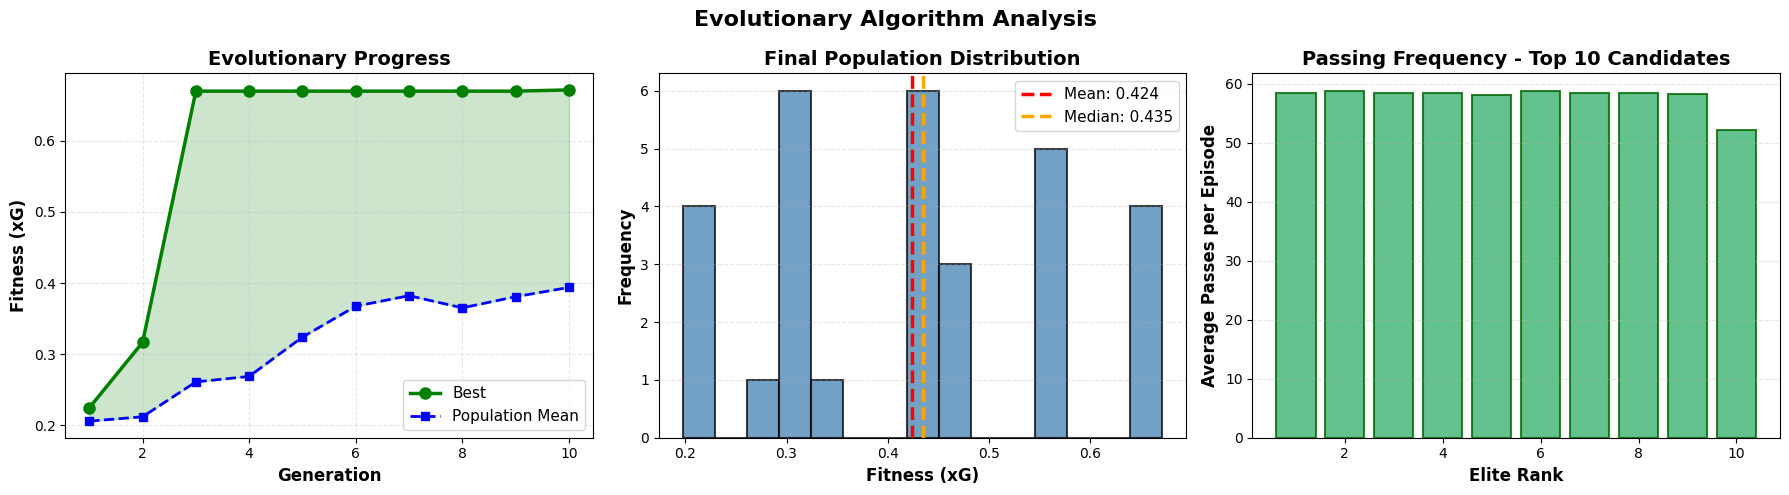

EVOLUTIONARY RUN ANALYSIS

Population size: 30
Generations executed: 10

Fitness Statistics (Final Generation):
  Best xG:      0.671
  Mean:         0.424
  Std Dev:      0.145
  Range:        [0.197, 0.671]

Evolutionary Improvement:
  Generation 1 best: 0.225
  Final best:        0.671
  Improvement:       +199.0%

Tactical Analysis (Top 10):
  Mean passes per episode: 57.8
  Max passes observed:     58.8


In [28]:
analyze_evolutionary_run(evolved_population, best_history, mean_history)

  Displayed 58 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


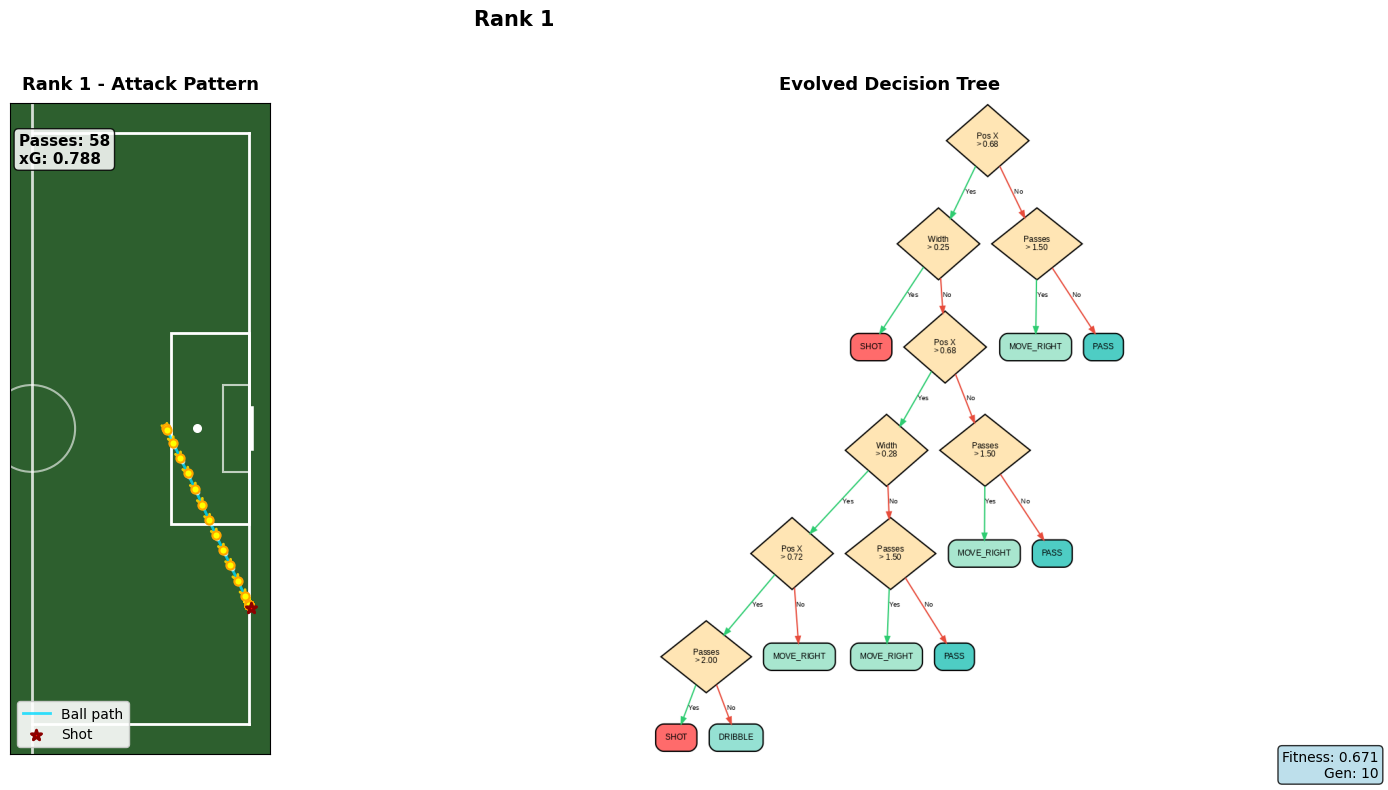


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0086889266967773, -0.25522372126579285]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


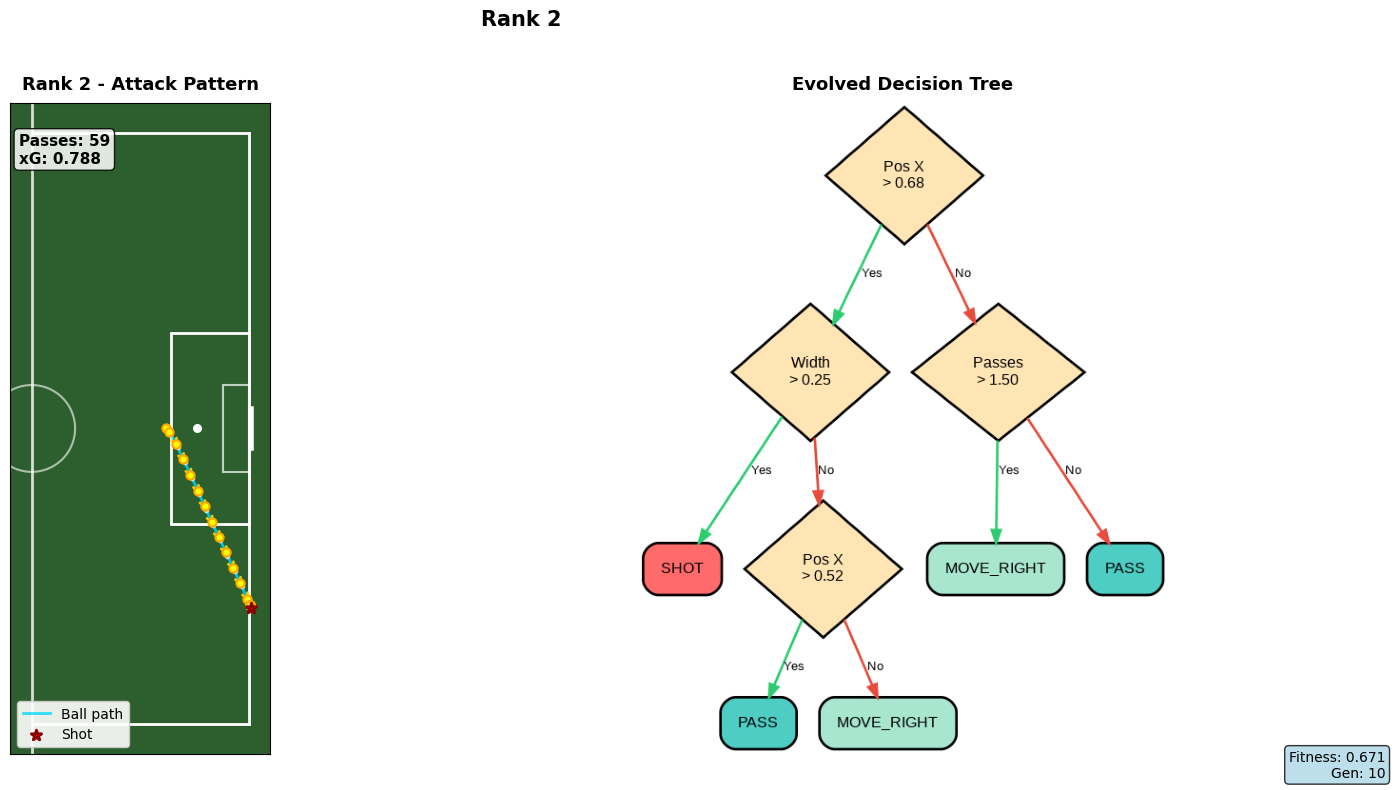


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0126910209655762, -0.2554003894329071]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


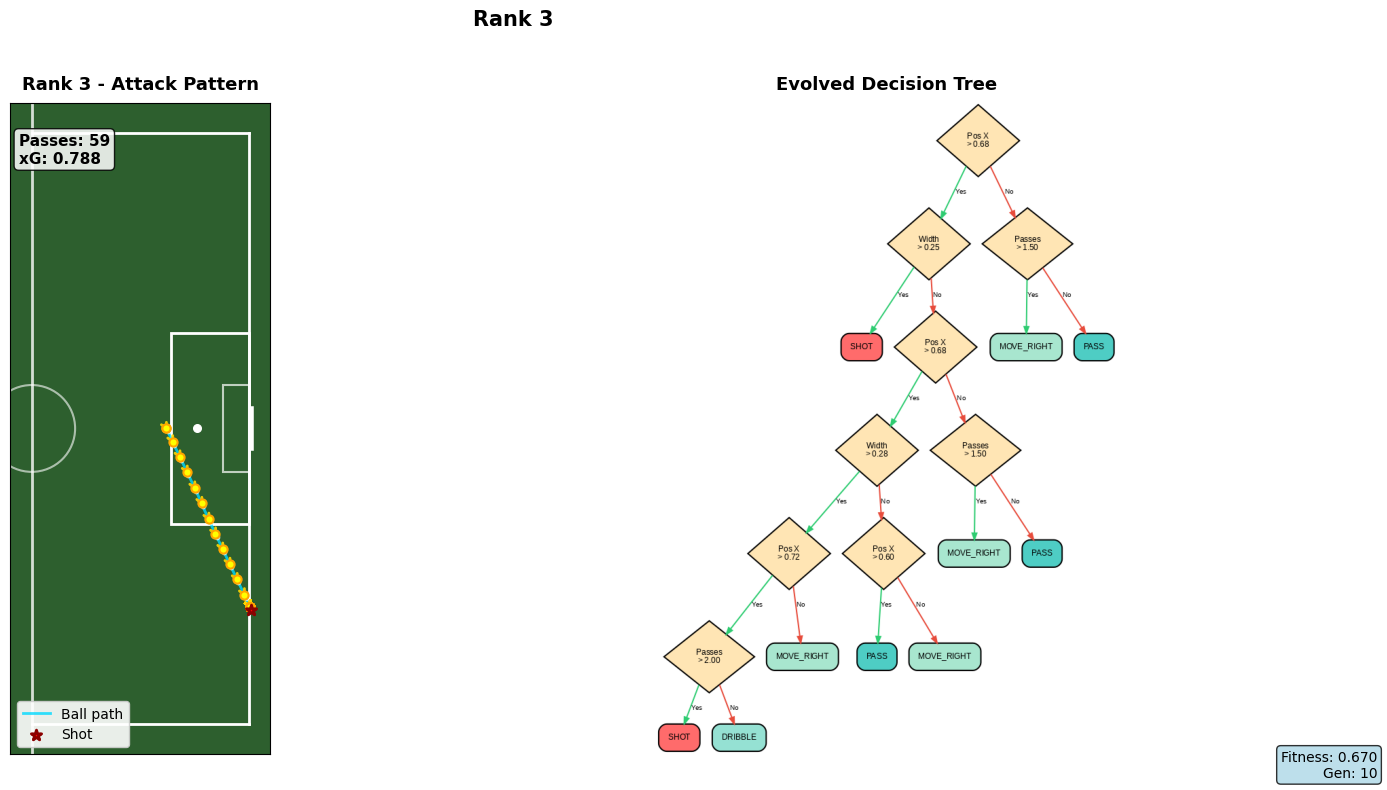


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0125670433044434, -0.25804629921913147]
  Recorded shot position: (0.930, -0.000)
  Displayed 58 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


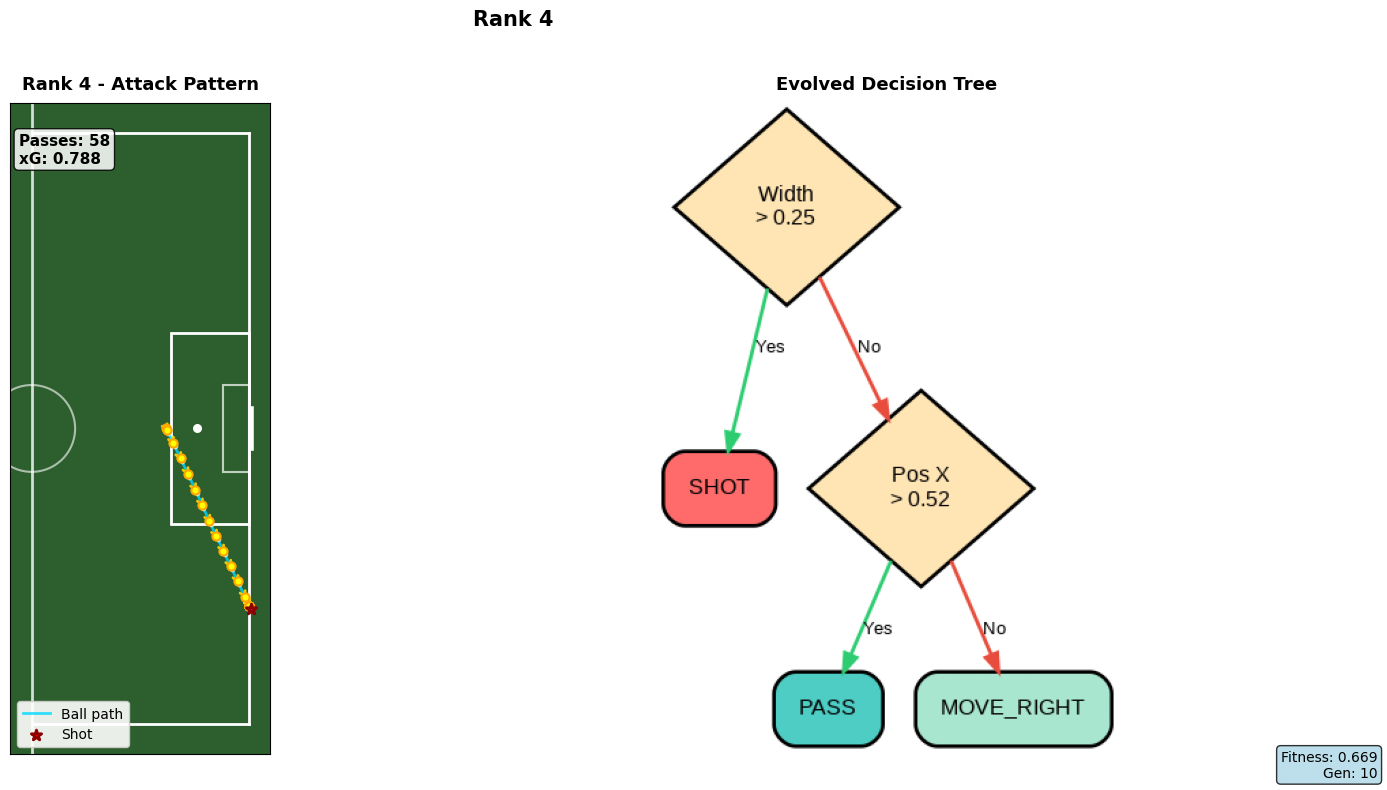


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0089117288589478, -0.2567526400089264]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


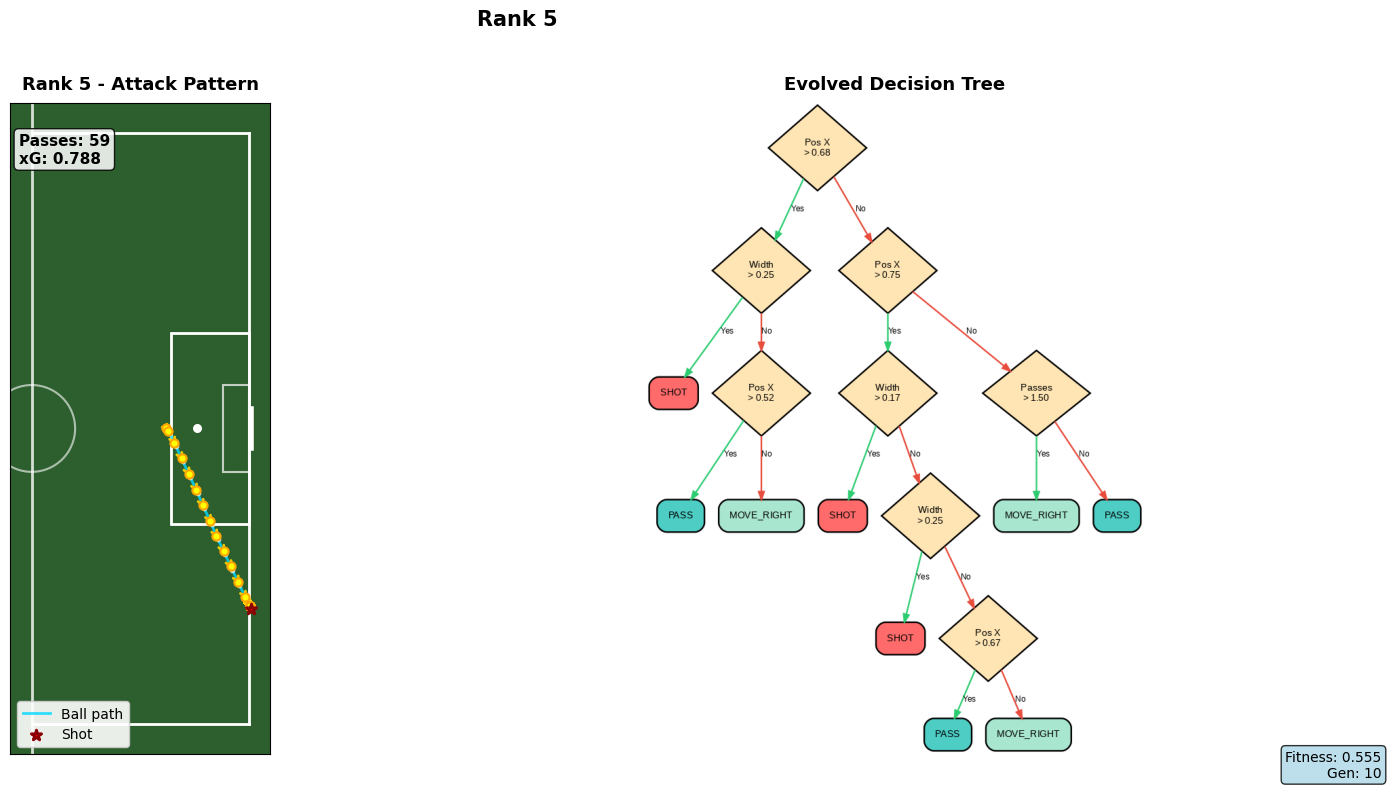


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0104931592941284, -0.2573384940624237]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


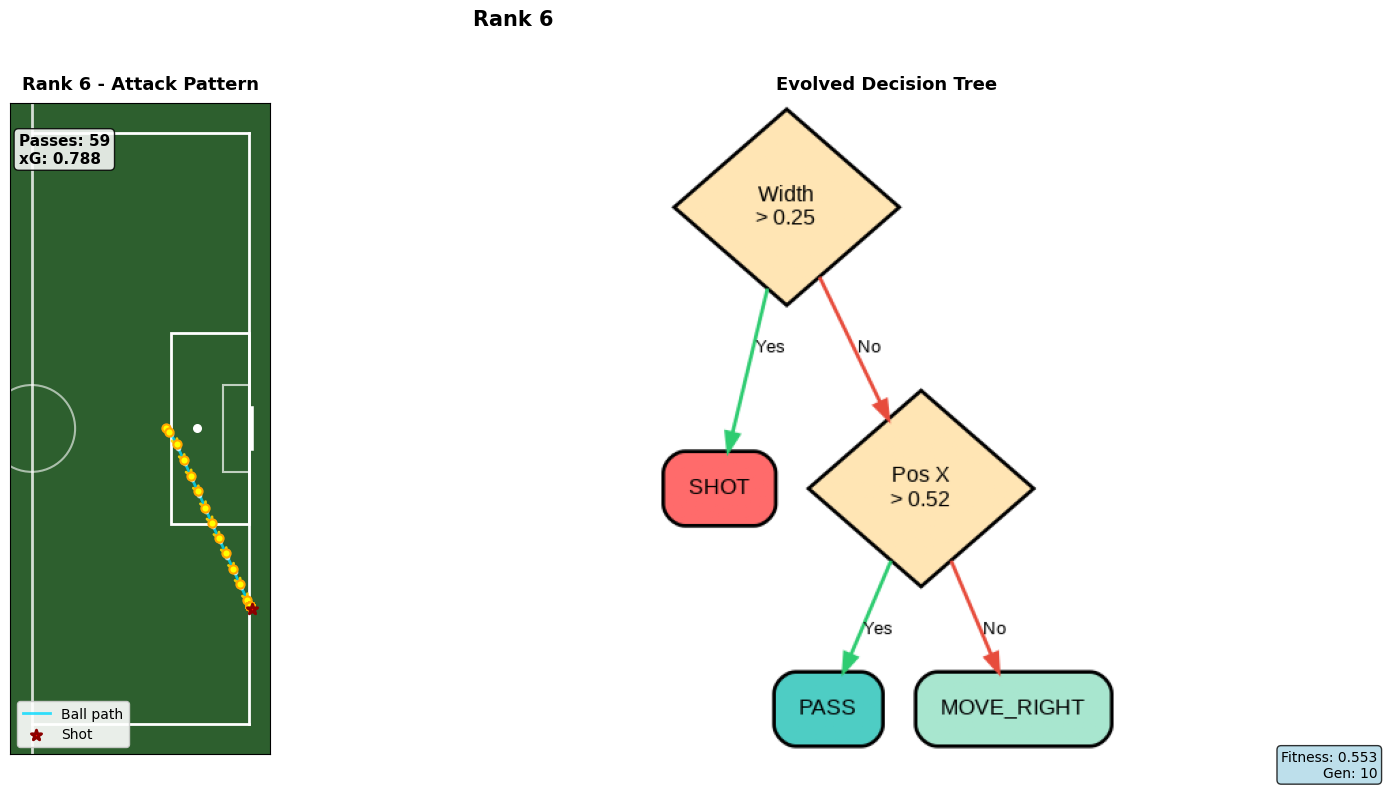


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0128825902938843, -0.2567838728427887]
  Recorded shot position: (0.930, -0.000)
  Displayed 58 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


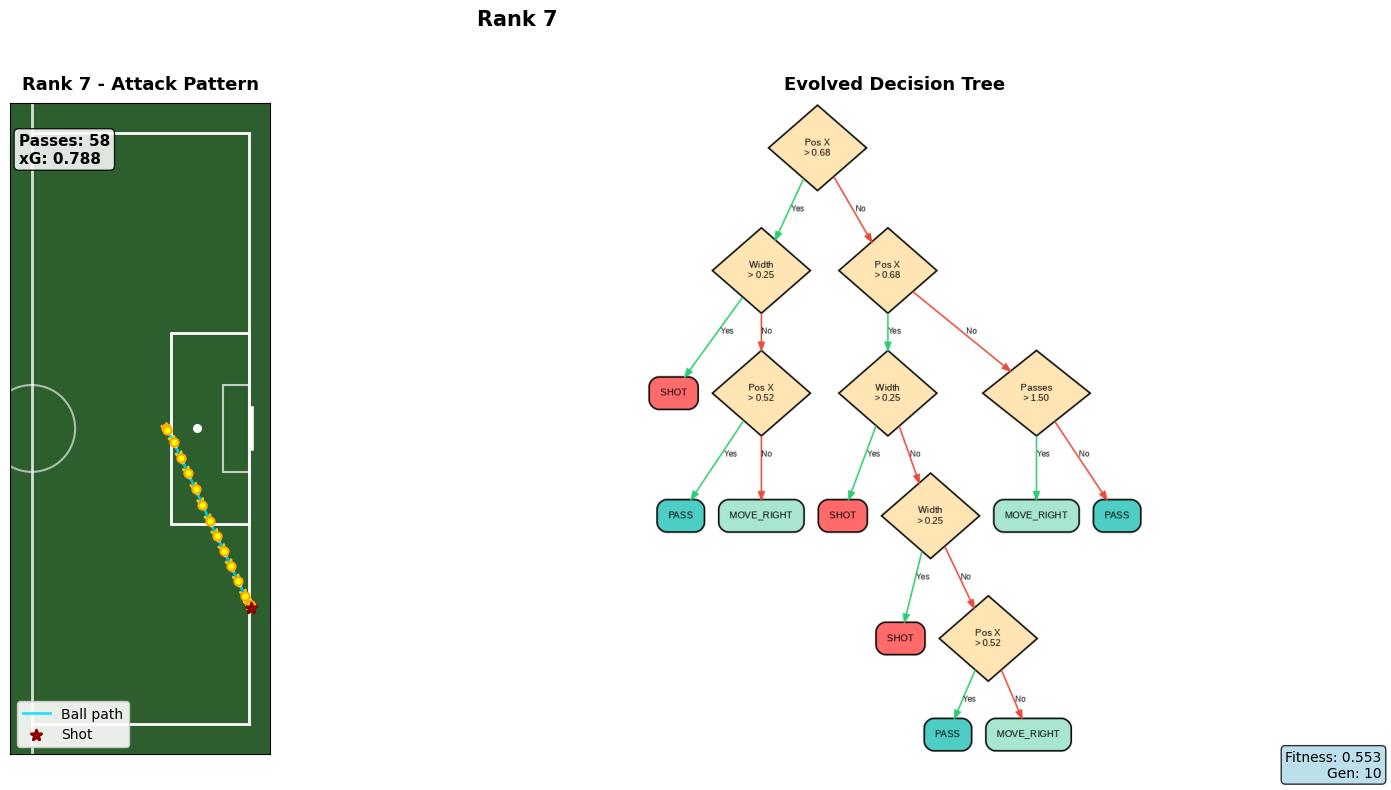


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0104371309280396, -0.2557929754257202]
  Recorded shot position: (0.930, -0.000)
  Displayed 58 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


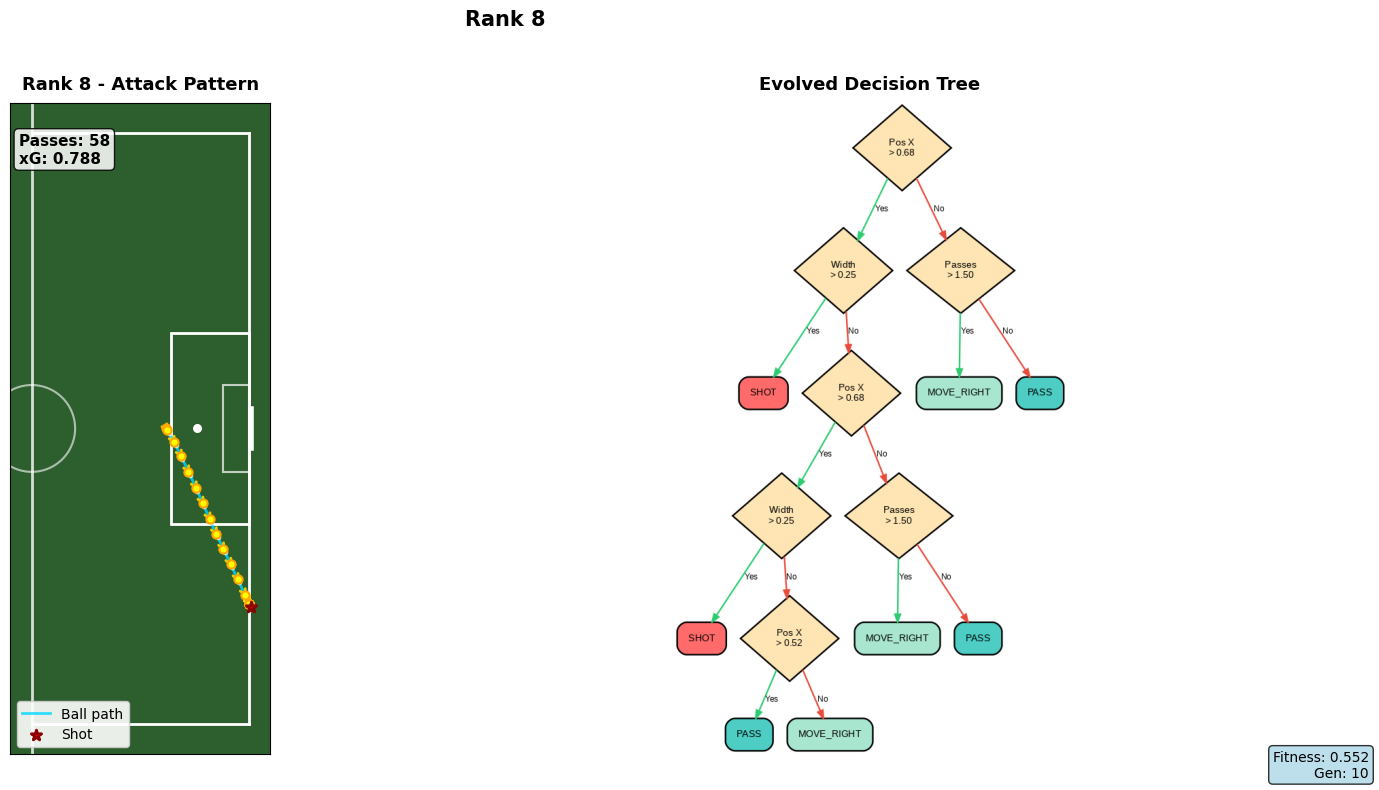


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0094647407531738, -0.2539162039756775]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


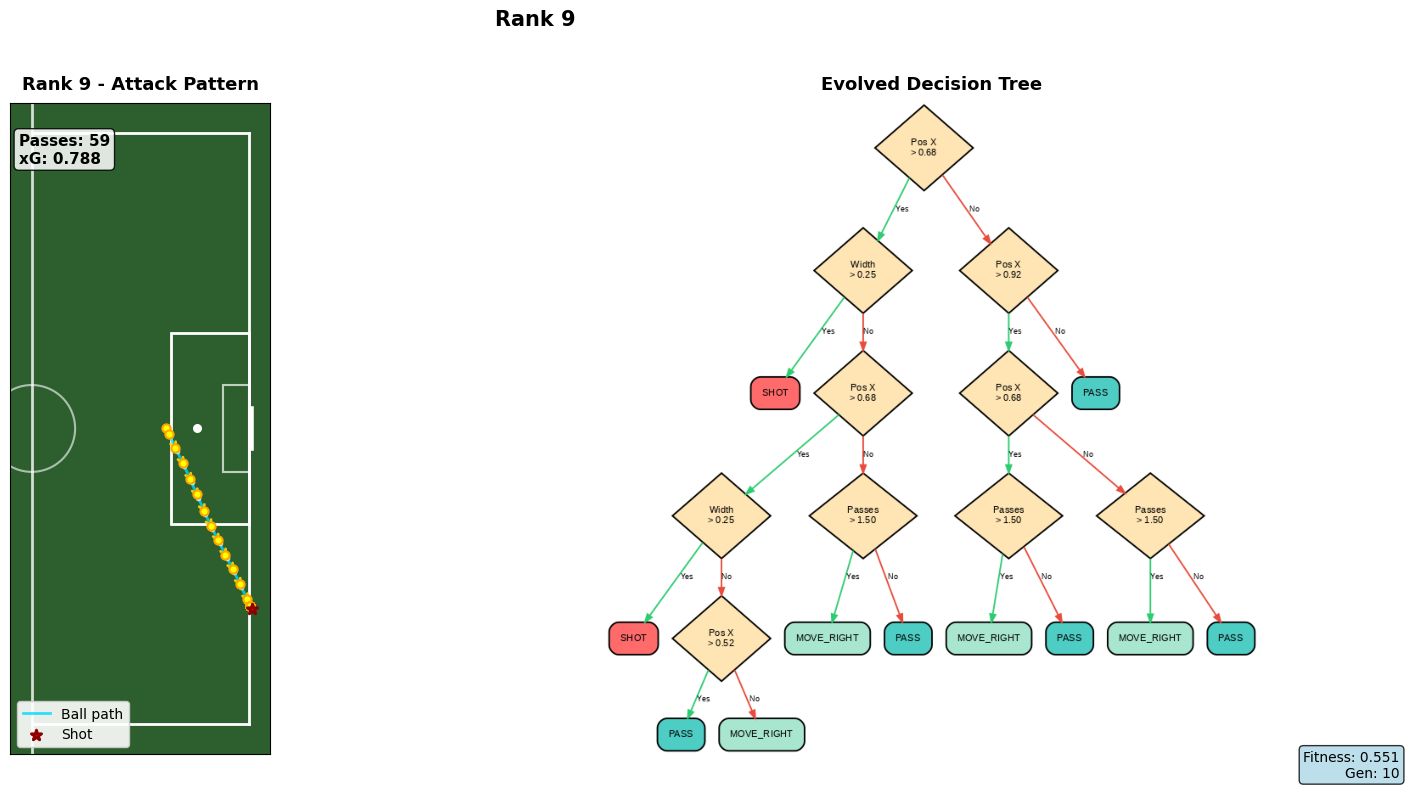


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0138596296310425, -0.25642094016075134]
  Recorded shot position: (0.930, -0.000)
  Displayed 59 passes in attacking half


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


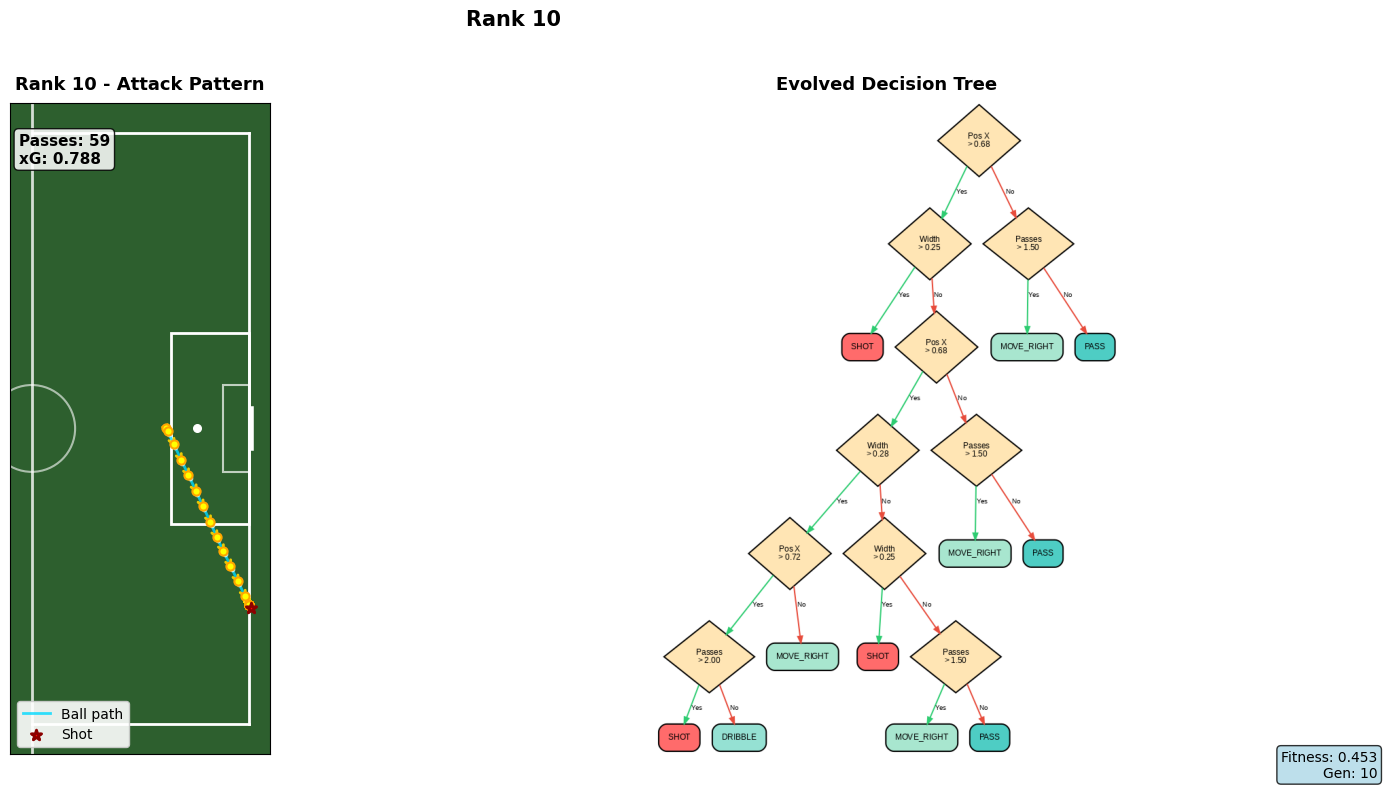


Trajectory info:
  Start position: [0.6200000047683716, -0.0]
  End position: [1.0095969438552856, -0.2560221552848816]
  Recorded shot position: (0.930, -0.000)


In [30]:
#top 10 solutions
for rank in range(10):
    if not evolved_population[rank].episode_records:
        evaluate_candidate_fitness(evolved_population[rank], num_evaluation_trials=5)
    visualize_candidate_solution(evolved_population[rank], f"Rank {rank+1}")